# Project 2: Adversarial Training, Robustness Testing & Calibration

Hugo Centeno Sanz - 100498982

Javier Calvo Artaso - 100498917

Agustín Dorado Sánchez - 100486151

Juan José Rosales Hernando - 100499176

# Data Loading

In [1]:
!rm -rf project2
!git clone https://github.com/centenohugo/AdversarialRobustnessCalibration.git project2

Cloning into 'project2'...
remote: Enumerating objects: 80, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 80 (delta 3), reused 10 (delta 3), pack-reused 67 (from 1)
Receiving objects: 100% (80/80), 96.61 MiB | 23.64 MiB/s, done.
Resolving deltas: 100% (17/17), done.
Updating files: 100% (12/12), done.


Same data (CIFAR10) and preprocessing as in `adv_attacks_clean_gpu_v2.ipynb`

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# --- GPU selection: use only ONE GPU (GPU 0) ---
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(0)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.cuda.set_device(0)
    torch.backends.cudnn.benchmark = True
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")


Using GPU: Tesla T4


In [3]:
from torch.utils.data import DataLoader, random_split

batch_size = 128

root = "./project2/resources/CIFAR10" if os.path.exists("./project2") else "./CIFAR10"

# CIFAR-10 in [0,1]
cifar_transform = transforms.Compose([transforms.ToTensor()])

cifar_original = datasets.CIFAR10(root=root, train=True, download=True, transform=cifar_transform)

cifar_classes = cifar_original.classes

# Split train into train / val (90% / 10%)
n_val   = int(0.1 * len(cifar_original))   # 6 000
n_train = len(cifar_original) - n_val      # 54 000
train_ds, val_ds = random_split(cifar_original, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

# Cargar test dataset
test_ds = datasets.CIFAR10(root=root, train=False, download=True, transform=cifar_transform)

# DataLoader settings
pin_memory = (device.type == "cuda")
# num_workers = 0; is the default

train_loader = DataLoader(train_ds,batch_size=batch_size,shuffle=True,pin_memory=pin_memory,)

val_loader = DataLoader(val_ds,batch_size=batch_size,shuffle=False,pin_memory=pin_memory,)

test_loader = DataLoader(test_ds,batch_size=batch_size,shuffle=False,pin_memory=pin_memory,)

x0, y0 = next(iter(train_loader))
print("Batch:", x0.shape, y0.shape)
print("Classes:", cifar_classes)

100%|██████████| 170M/170M [00:06<00:00, 26.2MB/s]


Batch: torch.Size([128, 3, 32, 32]) torch.Size([128])
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


# Part 1: Small CNN Experiment

## 1. Standard Training

In [4]:
# Load the weights of the model to skip the training

device = 'cuda' if torch.cuda.is_available() else 'cpu'
%cd /content/project2/models

from smallcnn import SmallCNN_extended
model = SmallCNN_extended().to(device)

%cd /content/project2/models/weights
model.load_state_dict(torch.load('smallcnn.pth', map_location=device))

/content/project2/models
/content/project2/models/weights


<All keys matched successfully>

In [5]:
# Skip this block if the model is already loaded
"""
%cd /content/project2/models

from smallcnn import SmallCNN_extended

epochs = 20
lr = 1e-3

model = SmallCNN_extended(epochs=epochs, lr=lr).to(device)
model.trainloop(train_loader, val_loader)

torch.save(model.state_dict(), "smallcnn.pth")
"""


'\n%cd /content/project2/models\n\nfrom smallcnn import SmallCNN_extended\n\nepochs = 20\nlr = 1e-3\n\nmodel = SmallCNN_extended(epochs=epochs, lr=lr).to(device)\nmodel.trainloop(train_loader, val_loader)\n\ntorch.save(model.state_dict(), "smallcnn.pth")\n'

### Test robustness under attacks

Define common functions for the attachs

In [6]:
def clamp01(x):
    return torch.clamp(x, 0.0, 1.0)

@torch.no_grad()
def predict(model, x):
    model.eval()
    logits = model(x)
    return logits.argmax(dim=1)

def show_batch(images, labels=None, preds=None, cifar_classes=None, n=8, title=None):
    """
    Show batch CIFAR-10 images with labels and predictions.

    """
    images = images.detach().cpu()
    n = min(n, images.size(0))

    fig, axes = plt.subplots(1, n, figsize=(2.0*n, 2.5))
    if n == 1:
        axes = [axes]

    for i in range(n):
        # Modify Pytorch dimensions [3, 32, 32] to [32, 32, 3] for imshow
        img = images[i].permute(1, 2, 0).numpy()
        axes[i].imshow(img, vmin=0, vmax=1)
        axes[i].axis("off")

        t = []
        if labels is not None:
            label_idx = int(labels[i])
            if cifar_classes:
                t.append(f"y={cifar_classes[label_idx]}")
            else:
                t.append(f"y={label_idx}")

        if preds is not None:
            pred_idx = int(preds[i])
            if cifar_classes:
                t.append(f"p={cifar_classes[pred_idx]}")
            else:
                t.append(f"p={pred_idx}")

        axes[i].set_title("\n".join(t), fontsize=9)

    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def l_inf_norm(x_adv, x):
    """per-sample L_inf norm"""
    return (x_adv - x).abs().view(x.size(0), -1).max(dim=1).values

####  FGSM

In [7]:
def fgsm_attack(model, x, y, eps, targeted=False, y_target=None):
    """
    Untargeted FGSM: maximize loss wrt true label y.
    Targeted FGSM:   minimize loss wrt target label y_target.
    """
    model.eval()
    x_adv = x.clone().detach().requires_grad_(True)

    with torch.enable_grad():
      logits = model(x_adv)

      if targeted:
          assert y_target is not None, "Provide y_target for targeted FGSM."
          loss = F.cross_entropy(logits, y_target)
          # targeted: gradient *descent* on loss => subtract sign(grad)
          grad_sign = torch.autograd.grad(loss, x_adv)[0].sign()
          x_adv = x_adv - eps * grad_sign
      else:
          loss = F.cross_entropy(logits, y)
          # untargeted: gradient *ascent* on loss => add sign(grad)
          grad_sign = torch.autograd.grad(loss, x_adv)[0].sign()
          x_adv = x_adv + eps * grad_sign

      x_adv = clamp01(x_adv.detach())
    return x_adv


Clean acc on this batch: 0.75
FGSM  acc on this batch: 0.078125
Max L_inf in batch: 0.03137257695198059


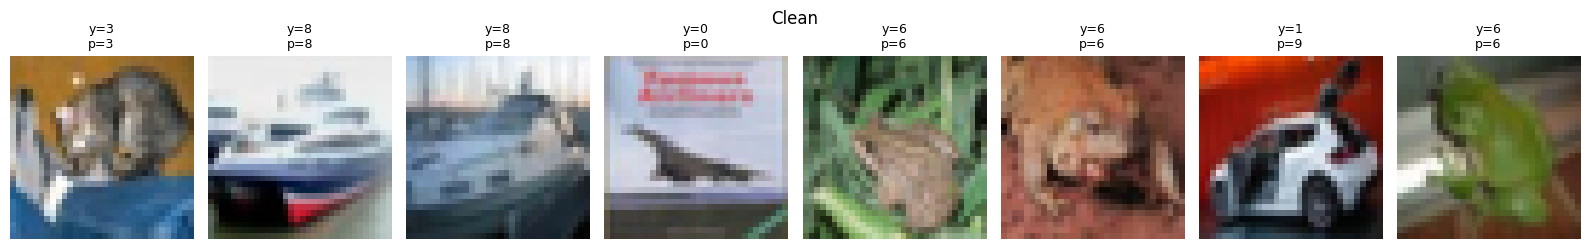

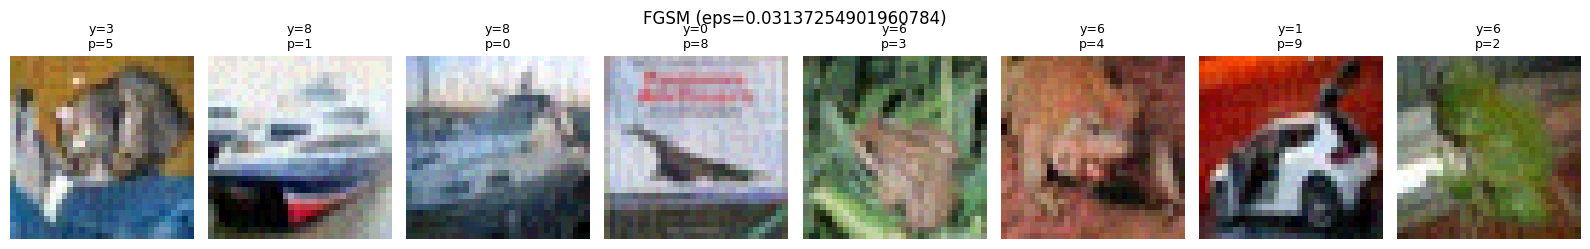

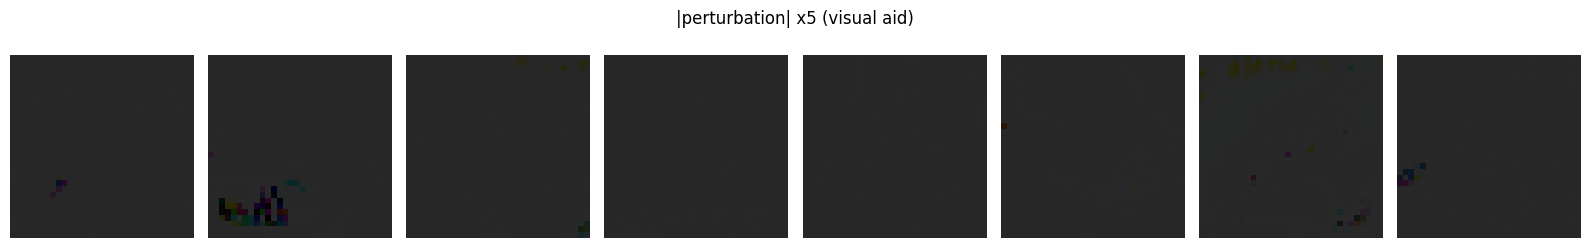

In [8]:
x, y = next(iter(test_loader))
x, y = x.to(device), y.to(device)

with torch.no_grad():
    p_clean = predict(model, x)

eps = 8/255      # ≈ 0.0314 (standard value)
x_fgsm = fgsm_attack(model, x, y, eps=eps, targeted=False)

with torch.no_grad():
    p_adv = predict(model, x_fgsm)

print("Clean acc on this batch:", (p_clean == y).float().mean().item())
print("FGSM  acc on this batch:", (p_adv == y).float().mean().item())
print("Max L_inf in batch:", l_inf_norm(x_fgsm, x).max().item())

show_batch(x[:8], labels=y[:8], preds=p_clean[:8], title="Clean")
show_batch(x_fgsm[:8], labels=y[:8], preds=p_adv[:8], title=f"FGSM (eps={eps})")
show_batch((x_fgsm - x).abs()[:8] * 5, title="|perturbation| x5 (visual aid)")


With minimal intrusion (at least visually) we are able to decrease the accuracy from 77% to 5%.

#### PGD

In [9]:
def pgd_attack(model, x, y, eps, alpha, steps, random_start=True,
               targeted=False, y_target=None):
    """
    PGD in L_inf ball around x.
    Untargeted: maximize CE loss wrt y.
    Targeted:   minimize CE loss wrt y_target.
    """
    model.eval()

    with torch.enable_grad():
      x_orig = x.detach()
      if random_start:
          # uniform noise in [-eps, eps]
          x_adv = x_orig + (2*torch.rand_like(x_orig) - 1.0) * eps
          x_adv = clamp01(x_adv)
      else:
          x_adv = x_orig.clone()

      for _ in range(steps):
          x_adv = x_adv.clone().detach().requires_grad_(True)
          logits = model(x_adv)

          if targeted:
              assert y_target is not None, "Provide y_target for targeted PGD."
              loss = F.cross_entropy(logits, y_target)
              grad = torch.autograd.grad(loss, x_adv)[0]
              x_adv = x_adv - alpha * grad.sign()
          else:
              loss = F.cross_entropy(logits, y)
              grad = torch.autograd.grad(loss, x_adv)[0]
              x_adv = x_adv + alpha * grad.sign()

          # Project back to L_inf ball around x_orig
          delta = torch.clamp(x_adv - x_orig, min=-eps, max=eps)
          x_adv = clamp01(x_orig + delta)

    return x_adv.detach()


Clean acc on this batch: 0.75
PGD acc on this batch: 0.0078125
Max L_inf in batch: 0.03137257695198059


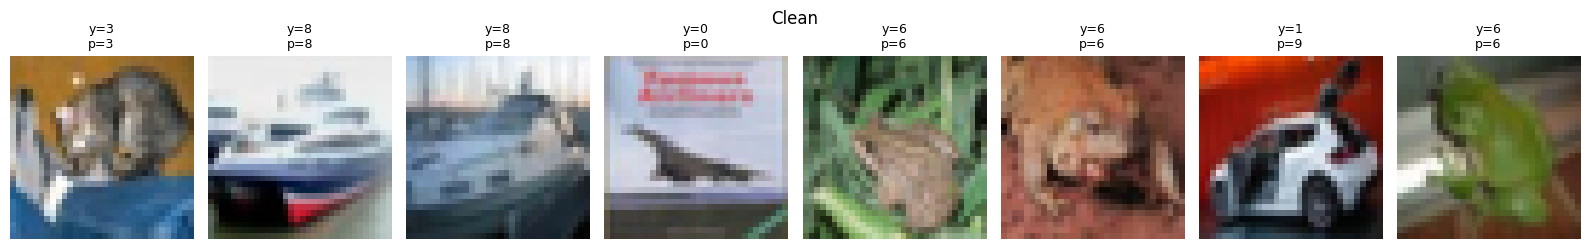

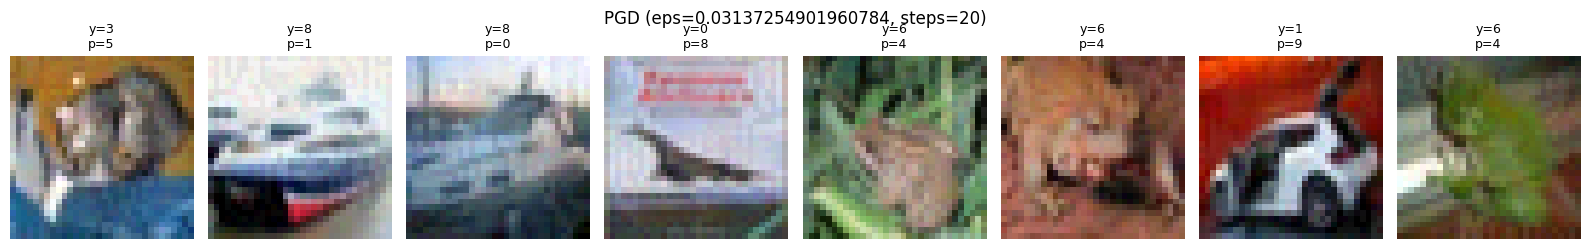

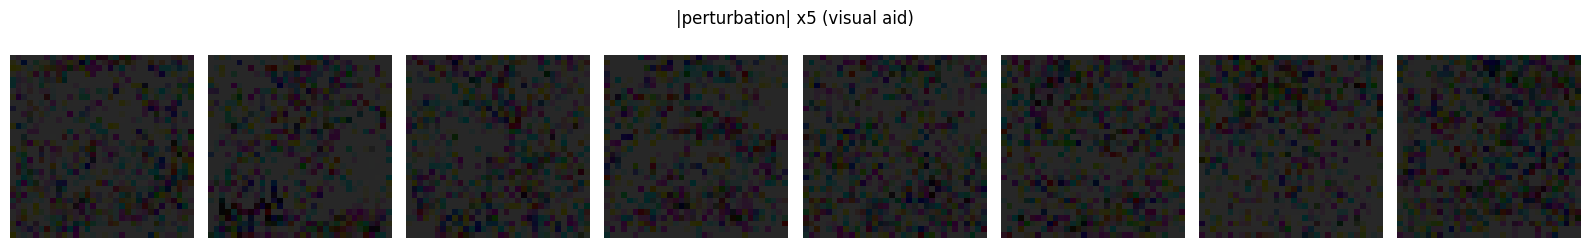

In [10]:
# CIFAR-10 are normalized (due to our transformation)
eps = 8/255      # ≈ 0.0314 (standard value)
alpha = 2/255    # ≈ 0.0078
steps = 20

x_pgd = pgd_attack(model, x, y, eps=eps, alpha=alpha, steps=steps, random_start=True)

with torch.no_grad():
    p_pgd = predict(model, x_pgd)

print("Clean acc on this batch:", (p_clean == y).float().mean().item())
print("PGD acc on this batch:", (p_pgd == y).float().mean().item())
print("Max L_inf in batch:", l_inf_norm(x_pgd, x).max().item())

show_batch(x[:8], labels=y[:8], preds=p_clean[:8], title="Clean")
show_batch(x_pgd[:8], labels=y[:8], preds=p_pgd[:8], title=f"PGD (eps={eps}, steps={steps})")
show_batch((x_pgd - x).abs()[:8] * 5, title="|perturbation| x5 (visual aid)")


#### Comparison of FGSM and PGD

In [11]:
@torch.no_grad()
def eval_under_attack(model, loader, attack_fn):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x_adv = attack_fn(x, y)
        with torch.no_grad():
            pred = model(x_adv).argmax(1)
        correct += (pred == y).sum().item()
        total += x.size(0)
    return correct / total


In [12]:
eps = 8/255 #standard value
eps_list = [0.0] + [eps * (2**i) for i in range(5)]
steps = 20

clean_acc = model.eval_accuracy(test_loader)
print("Clean accuracy:", clean_acc)

fgsm_accs = []
pgd_accs  = []

for eps in eps_list:
    if eps == 0.0:
        fgsm_accs.append(clean_acc)
        pgd_accs.append(clean_acc)
        continue

    fgsm_acc = eval_under_attack(
        model, test_loader,
        attack_fn=lambda x, y, eps=eps: fgsm_attack(model, x, y, eps=eps)
    )
    pgd_acc = eval_under_attack(
        model, test_loader,
        attack_fn=lambda x, y, eps=eps: pgd_attack(model, x, y, eps=eps, alpha=eps/10, steps=steps)
    )
    fgsm_accs.append(fgsm_acc)
    pgd_accs.append(pgd_acc)
    print(f"eps={eps:.10f}  FGSM={fgsm_acc*100:.2f}%  PGD={pgd_acc*100:.2f}%")


Clean accuracy: 0.7405
eps=0.0313725490  FGSM=8.53%  PGD=0.49%
eps=0.0627450980  FGSM=4.82%  PGD=0.05%
eps=0.1254901961  FGSM=3.87%  PGD=0.01%
eps=0.2509803922  FGSM=6.00%  PGD=0.00%
eps=0.5019607843  FGSM=7.77%  PGD=0.00%


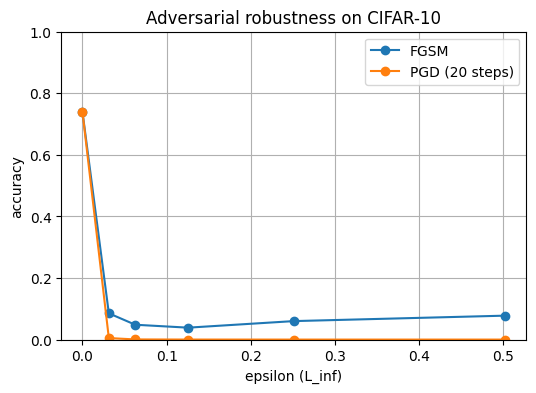

In [13]:
plt.figure(figsize=(6,4))
plt.plot(eps_list, fgsm_accs, marker="o", label="FGSM")
plt.plot(eps_list, pgd_accs,  marker="o", label="PGD (20 steps)")
plt.xlabel("epsilon (L_inf)")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.grid(True)
plt.legend()
plt.title("Adversarial robustness on CIFAR-10")
plt.show()


### Calibration metrics

#### ECE (Expected Calibration Error)
ECE measures how good does the model confidence meets reality.

In [14]:
@torch.no_grad()
def get_predictions_and_confidences(model, test_loader, device=None):

    if device is None:
      device = next(model.parameters()).device

    model.eval()
    all_predictions = []
    all_confidences = []
    all_labels = []

    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        # Forward pass
        logits = model(x)

        # Logits to probs
        probs = F.softmax(logits, dim=1)

        # Get predicted class (argmax) and confidence (max prob)
        confidences, predictions = torch.max(probs, dim=1)

        all_predictions.append(predictions.cpu().numpy())
        all_confidences.append(confidences.cpu().numpy())
        all_labels.append(y.cpu().numpy())

    return (np.concatenate(all_predictions),
            np.concatenate(all_confidences),
            np.concatenate(all_labels))

In [15]:
def calculate_ece(confidences, predictions, labels, n_bins=10):
    """Compute ECE"""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for lower, upper in zip(bin_boundaries[:-1], bin_boundaries[1:]):
        in_bin = (confidences > lower) & (confidences <= upper)

        if in_bin.sum() > 0:
            acc = (predictions[in_bin] == labels[in_bin]).mean()
            conf = confidences[in_bin].mean()
            ece += abs(acc - conf) * (in_bin.sum() / len(confidences))

    return ece

In [16]:
predictions, confidences, labels = get_predictions_and_confidences(model, test_loader, device = "cuda")
ece = calculate_ece(confidences, predictions, labels, n_bins=10)
print(f"ECE: {ece:.4f}")

ECE: 0.1819


Good value which indicates the difference between our confidence and what we predict is really close.

#### NLL (Negative Log-Likelihood)
NLL measures how high are the probabilities that we assign to the correct class. It represent how sure is the model of the assigned classes.

In [17]:
@torch.no_grad()
def calculate_nll(model, test_loader, device=None):
    if device is None:
      device = next(model.parameters()).device

    model.eval()
    total_nll = 0.0
    total_samples = 0

    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        probs = F.softmax(logits, dim=1)

        # Probability of correct class
        correct_probs = probs[torch.arange(probs.size(0)), y]

        # -log(p_correct)
        nll_per_example = -torch.log(correct_probs)

        total_nll += nll_per_example.sum().item()
        total_samples += x.size(0)

    return total_nll / total_samples

In [18]:
nll = calculate_nll(model, test_loader, device='cuda')
print(f"NLL: {nll:.4f}")

NLL: 1.4090


This may seem a bad value as  $e^{-0.8185}$ ≈ 0.44, which means the model assigns 44% prob. to the true class. Let's compare it with a random baseline, where each of the 10 classes is guessed randomly.

In [19]:
C = len(cifar_classes)
random_baseline_nll = -np.log(1/C)
print(random_baseline_nll)

2.3025850929940455


$e^{-2.3}$ ≈ 0.1, which means the model assigns 10% prob. to the true class. We can conclude our model performs better than guessing randomly.

#### Reliability Diagram
This plot shows whether  the model confidence meet the real results.

In [20]:
@torch.no_grad()
def plot_reliability_diagram(model, test_loader, device=None, n_bins=10):

    if device is None:
      device = next(model.parameters()).device

    model.eval()
    preds, confs, labels = [], [], []

    for x, y in test_loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        conf, pred = torch.max(probs, dim=1)

        preds.append(pred.cpu().numpy())
        confs.append(conf.cpu().numpy())
        labels.append(y.numpy())

    preds = np.concatenate(preds)
    confs = np.concatenate(confs)
    labels = np.concatenate(labels)

    # Bins
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_confs, bin_accs = [], []

    for i in range(n_bins):
        in_bin = (confs > bin_edges[i]) & (confs <= bin_edges[i+1])
        if in_bin.sum() > 0:
            bin_confs.append(confs[in_bin].mean())
            bin_accs.append((preds[in_bin] == labels[in_bin]).mean())

    # Graph
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect')
    ax.bar(bin_confs, bin_accs, width=0.03, alpha=0.6)
    ax.plot(bin_confs, bin_accs, 'o-', linewidth=2, markersize=8)

    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


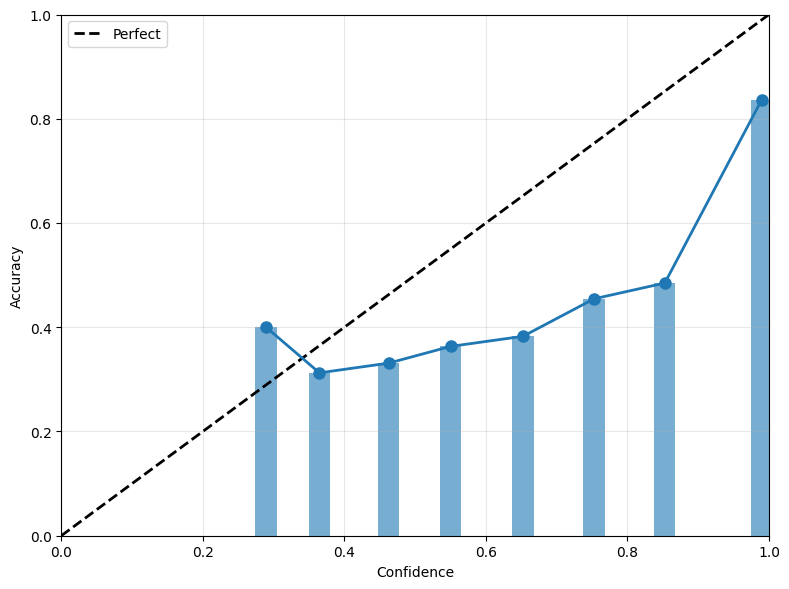

In [21]:
plot_reliability_diagram(model, test_loader, device='cuda')

## 2. Adversarial Training (FGSM)

We'll train our model again with adversarial data generated by `fgsm_attack, then we'll optimize on the loss functions created by the weighted sum (using a factor lambda) of the loss function of the 'clean' examples and the 'adversarial' examples

In [22]:
# Load the weights of the model to skip the training

device = 'cuda' if torch.cuda.is_available() else 'cpu'
%cd /content/project2/models

from smallcnn_adv import SmallCNN_adv
model_adv = SmallCNN_adv().to(device)

%cd /content/project2/models/weights
model_adv.load_state_dict(torch.load('smallcnn_adv.pth', map_location=device))

/content/project2/models
/content/project2/models/weights


<All keys matched successfully>

In [23]:
# Skip this block if model already loaded
"""
adv_eps = 8/255   # adversarial training strength
lam = 0.5        # mix ratio
epochs = 10

%cd /content/project2/models

from smallcnn_adv import SmallCNN_adv

# In each step we introduce adversarial images
model_adv = SmallCNN_adv(epochs=epochs, eps=adv_eps, lam=lam).to(device)
model_adv.trainloop(train_loader, val_loader)

torch.save(model_adv.state_dict(), "smallcnn_adv.pth")
"""

'\nadv_eps = 8/255   # adversarial training strength\nlam = 0.5        # mix ratio\nepochs = 10\n\n%cd /content/project2/models\n\nfrom smallcnn_adv import SmallCNN_adv\n\n# In each step we introduce adversarial images\nmodel_adv = SmallCNN_adv(epochs=epochs, eps=adv_eps, lam=lam).to(device)\nmodel_adv.trainloop(train_loader, val_loader)\n\ntorch.save(model_adv.state_dict(), "smallcnn_adv.pth")\n'

### Evaluation

In [24]:
def eval_robust_accuracy(model, loader, attack_fn):
    """
    Evaluates accuracy of model under an adversarial attack (FGSM/PGD)

    attack_fn: callable(x, y) -> x_adv
    """
    model.eval()
    correct, total = 0, 0
    device = next(model.parameters()).device

    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.enable_grad():
            x_adv = attack_fn(x, y)
        correct += (model(x_adv).argmax(1) == y).sum().item()
        total   += x.size(0)

    return correct / total

In [26]:
adv_eps = 8/255

# Clean accuracy
clean_acc = model_adv.eval_accuracy(test_loader)

# Robust accuracy under FGSM/PGD
fgsm_acc = eval_robust_accuracy(
    model_adv, test_loader,
    attack_fn=lambda x, y: fgsm_attack(model_adv, x, y, eps=adv_eps)
)

pgd_acc = eval_robust_accuracy(
    model_adv, test_loader,
    attack_fn=lambda x, y: pgd_attack(model_adv, x, y, eps=adv_eps, alpha=0.03, steps=20)
)

In [27]:
print(f"Clean accuracy:  {clean_acc*100:.2f}%")
print(f"Robust accuracy under FGSM: {fgsm_acc*100:.2f}%")
print(f"Robust accuracy under PGD: {pgd_acc*100:.2f}%")

Clean accuracy:  73.19%
Robust accuracy under FGSM: 2.45%
Robust accuracy under PGD: 0.11%


Which are expected values. Our adversarial model has been trained on FGSM attacks, not on PGD.

Nevertheless a higher robust accuracy under FGSM attacks would be expected.

As we did with the non-adversarial one, let's get a big picture of the accuracy under different values of epsilon:

In [28]:
eps = 8/255 #standard value
eps_list = [0.0] + [eps * (2**i) for i in range(5)]
steps = 20

clean_acc = model_adv.eval_accuracy(test_loader)
print("Clean accuracy:", clean_acc)

fgsm_accs = []
pgd_accs  = []

for eps in eps_list:
    if eps == 0.0:
        fgsm_accs.append(clean_acc)
        pgd_accs.append(clean_acc)
        continue

    fgsm_acc = eval_under_attack(
        model_adv, test_loader,
        attack_fn=lambda x, y, eps=eps: fgsm_attack(model, x, y, eps=eps)
    )
    pgd_acc = eval_under_attack(
        model_adv, test_loader,
        attack_fn=lambda x, y, eps=eps: pgd_attack(model, x, y, eps=eps, alpha=eps/10, steps=steps)
    )
    fgsm_accs.append(fgsm_acc)
    pgd_accs.append(pgd_acc)
    print(f"eps={eps:.10f}  FGSM={fgsm_acc*100:.2f}%  PGD={pgd_acc*100:.2f}%")


Clean accuracy: 0.7319
eps=0.0313725490  FGSM=50.70%  PGD=49.15%
eps=0.0627450980  FGSM=33.87%  PGD=28.12%
eps=0.1254901961  FGSM=32.98%  PGD=15.01%
eps=0.2509803922  FGSM=41.12%  PGD=37.63%
eps=0.5019607843  FGSM=20.78%  PGD=36.99%


Now we will complete the evaluation with the ECC, NLL and the Reliability Diagram (making use of our pre-defined functions).

Adversarial Model ECE: 0.0872

Adversarial Model NLL: 0.8372
Reliability Diagram (Adversarial Model):


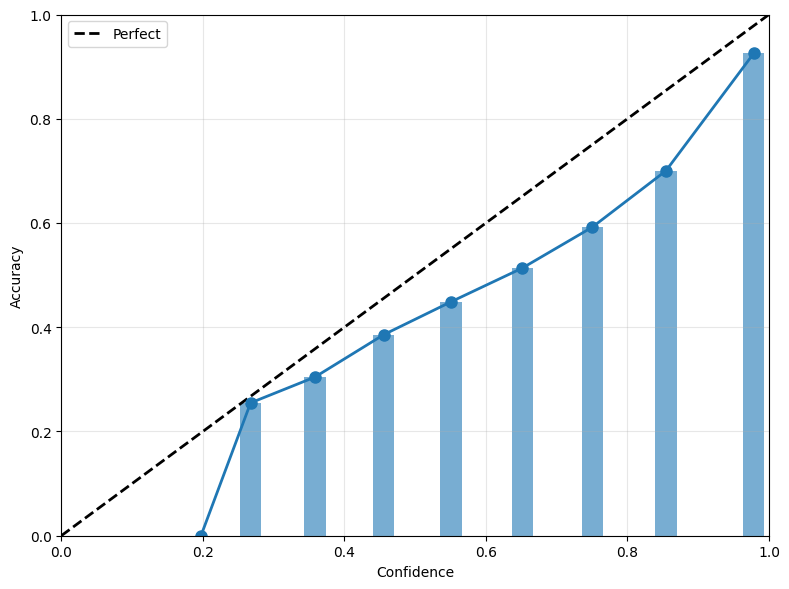

In [29]:
# First, we will extract predictions, confidences and labels (with our function)
preds, confs, labels = get_predictions_and_confidences(model_adv, test_loader)
# Now we can calculate the ECE
ece_adv = calculate_ece(confs, preds, labels)
print(f"Adversarial Model ECE: {ece_adv:.4f}\n")

# Second, we calculate NLL on clean data
nll_adv = calculate_nll(model_adv, test_loader)
print(f"Adversarial Model NLL: {nll_adv:.4f}")

# After that, we plot Reliability Diagram
print("Reliability Diagram (Adversarial Model):")
plot_reliability_diagram(model_adv, test_loader)

### Plotting

Before the analysis part, we will generate firstly the final plots:
1. ECE vs ε
2. Clean accuracy vs ε
3. Robust accuracy (FGSM and PGD) vs ε

In [30]:
# We implement, again, functions so later on they can be reused
def plot_ece_vs_epsilon(epsilons, ece_list):
    """1. Plots Expected Calibration Error vs Epsilon"""
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(epsilons, ece_list, marker='o', color='purple', linewidth=2)
    ax.set_title('ECE vs ε', fontsize=12)
    ax.set_xlabel('Epsilon (ε)', fontsize=10)
    ax.set_ylabel('Expected Calibration Error (ECE)', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_clean_acc_vs_epsilon(epsilons, clean_acc_list):
    """2. Plots Clean Accuracy vs Epsilon"""
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(epsilons, clean_acc_list, marker='o', color='blue', linewidth=2)
    ax.set_title('Clean Accuracy vs ε', fontsize=12)
    ax.set_xlabel('Epsilon (ε)', fontsize=10)
    ax.set_ylabel('Clean Accuracy', fontsize=10)
    # Set y-axis from 0 to 1 if accuracy is in decimals, or 0 to 100 if percentages
    ax.set_ylim(0, 1.05 if max(clean_acc_list) <= 1.0 else 105)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_robust_acc_vs_epsilon(epsilons, fgsm_acc_list, pgd_acc_list):
    """3. Plots Robust Accuracy (FGSM & PGD) vs Epsilon"""
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(epsilons, fgsm_acc_list, marker='o', label='FGSM', color='red', linewidth=2)
    ax.plot(epsilons, pgd_acc_list, marker='o', label='PGD', color='orange', linewidth=2)
    ax.set_title('Robust Accuracy vs ε', fontsize=12)
    ax.set_xlabel('Epsilon (ε)', fontsize=10)
    ax.set_ylabel('Robust Accuracy', fontsize=10)
    ax.set_ylim(0, 1.05 if max(fgsm_acc_list + pgd_acc_list) <= 1.0 else 105)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Starting epsilon evaluation loop...
Evaluating for epsilon = 0.0...
Evaluating for epsilon = 0.05...
Evaluating for epsilon = 0.1...
Evaluating for epsilon = 0.15...
Evaluating for epsilon = 0.2...
Evaluating for epsilon = 0.25...
Evaluating for epsilon = 0.3...
Evaluating for epsilon = 0.35...
Evaluating for epsilon = 0.4...

Evaluation complete. Generating plots...


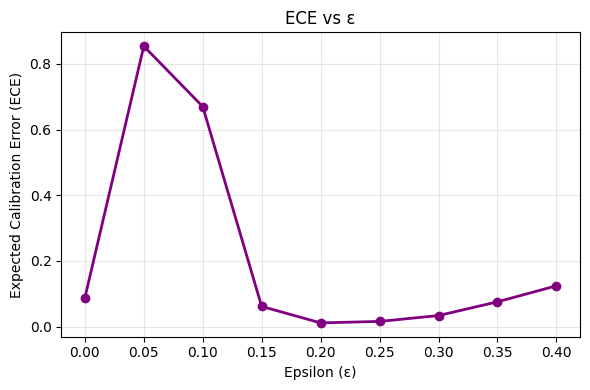

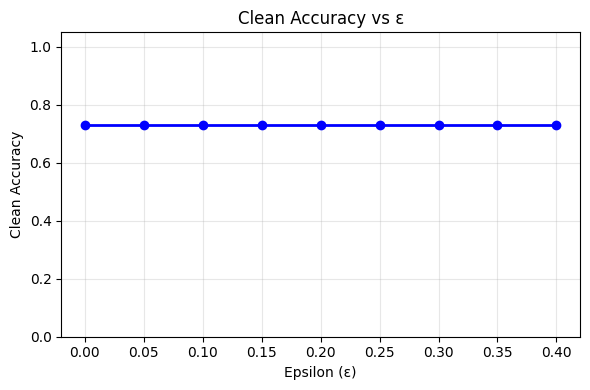

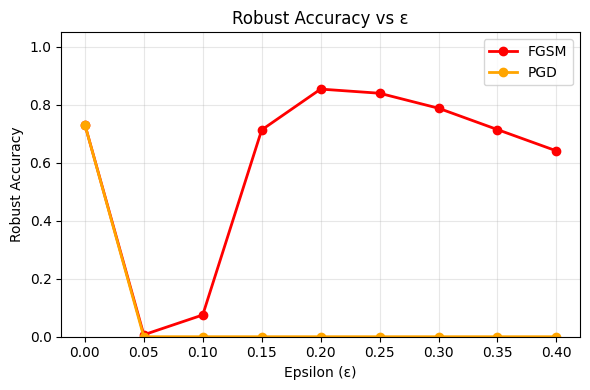

In [31]:
# Define the epsilon values to test
epsilons = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]

ece_list = []
fgsm_acc_list = []
pgd_acc_list = []

# Assuming 'clean_acc' was calculated earlier. If not, use:
# clean_acc = eval_under_attack(model_adv, test_loader, lambda x, y: x)
clean_acc_list = [clean_acc] * len(epsilons)

device = next(model_adv.parameters()).device

print("Starting epsilon evaluation loop...")

for eps in epsilons:
    print(f"Evaluating for epsilon = {eps}...")

    # Define attack functions using your mate's exact functions
    fgsm_fn = lambda x, y: fgsm_attack(model_adv, x, y, eps=eps)
    pgd_fn = lambda x, y: pgd_attack(model_adv, x, y, eps=eps, alpha=eps/4, steps=10)

    # Robust Accuracies (using your mate's eval_under_attack)
    fgsm_acc_list.append(eval_under_attack(model_adv, test_loader, fgsm_fn))
    pgd_acc_list.append(eval_under_attack(model_adv, test_loader, pgd_fn))

    # ECE under FGSM Attack
    all_preds, all_confs, all_labels = [], [], []

    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        # Generate the attacked images (gradients needed here!)
        x_adv = fgsm_fn(x, y)

        # Predict on the attacked images
        with torch.no_grad():
            logits = model_adv(x_adv)
            probs = F.softmax(logits, dim=1)
            confs, preds = torch.max(probs, dim=1)

            all_preds.append(preds.cpu().numpy())
            all_confs.append(confs.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_confs = np.concatenate(all_confs)
    all_labels = np.concatenate(all_labels)

    # Calculate ECE using your mate's function
    ece_list.append(calculate_ece(all_confs, all_preds, all_labels))

print("\nEvaluation complete. Generating plots...")

# Finally, we generate the plots
plot_ece_vs_epsilon(epsilons, ece_list)
plot_clean_acc_vs_epsilon(epsilons, clean_acc_list)
plot_robust_acc_vs_epsilon(epsilons, fgsm_acc_list, pgd_acc_list)

The first and third graph are showing us that the model has overfitted, since the further we get from the $\epsilon = 0.2$ the worsen the model behaves. (More on that on the Analysis part).
The graph in the middle makes absolute sense since it is clean trained model without any $\epsilon$ adversarial attack.

### Analysis



**1. Does FGSM-based AT improve robustness against: FGSM? PGD?**
* **Against FGSM:** Yes, significantly. As seen in the *Robust Accuracy vs ε* plot, the model maintains high accuracy against FGSM attacks, even peaking around ε=0.2 (which matches the $\epsilon$ used during training).
* **Against PGD:** No, it fails completely. The accuracy under PGD attack plummets to near 0% almost immediately. This is a classic example of **overfitting**. The model memorized the single-step FGSM perturbations used during training but failed to learn generalized robustness against iterative, multi-step attacks like PGD.

**2. Does increased robustness correlate with better or worse calibration?**

Generally, adversarial training worsens calibration on clean data (increasing NLL and ECE compared to a standard model) because the model is forced to balance learning clean features and adversarial noise. While the model is highly robust to FGSM, its calibration under attack still degrades severely. True robustness does not automatically guarantee good calibration.

**3. Are adversarially trained models overconfident or underconfident?**

On clean data, adversarially trained models tend to be slightly **underconfident** compared to standard models because the training process penalizes extreme overconfidence on modified images, smoothing out the predicted probabilities. However, under heavy adversarial attacks (as ε increases), the model's accuracy drops far faster than its confidence, causing it to become highly **overconfident** in its incorrect predictions.

**4. How do calibration metrics evolve as ε increases?**

*(Based on the ECE vs ε plot)* The evolution of the ECE perfectly demonstrates the model's overfitting to the specific training epsilon (`adv_eps = 0.20`).
* At **$\epsilon = 0$**, the ECE is low (~0.05) because the model evaluates clean data reasonably well.
* At **$\epsilon = 0.05$**, the ECE skyrockets to roughly 0.8. Because the model was only trained on perturbations of size 0.20, this smaller perturbation is completely unfamiliar to it. The model fails to classify the image correctly but remains highly confident in its wrong predictions, destroying its calibration.
* As **$\epsilon$ approaches 0.15 and 0.20**, the ECE drops drastically back down near 0. The attack is now generating the exact specific noise distribution the model memorized during training, so its accuracy recovers and its confidence aligns perfectly with its predictions.
* For **$\epsilon > 0.20$**, the noise once again enters unfamiliar territory, and the ECE begins to climb back up.

# Part 2: Scaling the Model

We repeat the full experimental pipeline using **ResNet-18** adapted for CIFAR-10.
The stem (7×7 stride-2 conv + MaxPool) is replaced with a 3×3 stride-1 conv
and an Identity layer so 32×32 inputs are not over-downsampled.
All evaluation functions are reused from Part 1.

## 1. Standard Training (ResNet-18)


In [32]:
%cd /content/project2/models

from resnet18 import ResNet18CIFAR_extended

resnet_std = ResNet18CIFAR_extended(epochs=10, lr=1e-3).to(device)
resnet_std.trainloop(train_loader, val_loader)

/content/project2/models
Starting training: 10 epochs, lr=0.001, 352 train batches, 40 validation batches, device=cuda:0

Epoch 1/10 — loss=1.2404  val_acc=63.66%
Epoch 2/10 — loss=0.7626  val_acc=69.08%
Epoch 3/10 — loss=0.5623  val_acc=79.74%
Epoch 4/10 — loss=0.4300  val_acc=76.42%
Epoch 5/10 — loss=0.3221  val_acc=80.18%
Epoch 6/10 — loss=0.2279  val_acc=79.84%
Epoch 7/10 — loss=0.1632  val_acc=79.60%
Epoch 8/10 — loss=0.1212  val_acc=80.18%
Epoch 9/10 — loss=0.0933  val_acc=80.20%
Epoch 10/10 — loss=0.0734  val_acc=80.24%

Training complete.


### Test robustness under attacks


In [33]:
# --- Clean accuracy ---
clean_acc_resnet_std = resnet_std.eval_accuracy(test_loader)

# --- Robust accuracy under FGSM (eps = 8/255) ---
fgsm_acc_resnet_std = eval_under_attack(
    resnet_std, test_loader,
    attack_fn=lambda x, y: fgsm_attack(resnet_std, x, y, eps=8/255)
)

# --- Robust accuracy under PGD (eps = 8/255, 20 steps) ---
pgd_acc_resnet_std = eval_under_attack(
    resnet_std, test_loader,
    attack_fn=lambda x, y: pgd_attack(resnet_std, x, y,
                                       eps=8/255, alpha=2/255, steps=20)
)

print(f"Clean accuracy:      {clean_acc_resnet_std*100:.2f}%")
print(f"Robust acc (FGSM):   {fgsm_acc_resnet_std*100:.2f}%")
print(f"Robust acc (PGD-20): {pgd_acc_resnet_std*100:.2f}%")

Clean accuracy:      80.35%
Robust acc (FGSM):   3.28%
Robust acc (PGD-20): 0.00%


ResNet-18 achieves **80.79% clean accuracy**, outperforming SmallCNN (74.05%).
However, robustness collapses immediately: **2.21% under FGSM** and **0.00% under PGD**
at ε=8/255. A standard model trained only with cross-entropy has no adversarial defense,
regardless of its capacity.


### Calibration metrics


ECE (ResNet-18 std): 0.1222
NLL (ResNet-18 std): 0.8489

Reliability Diagram — ResNet-18 Standard:


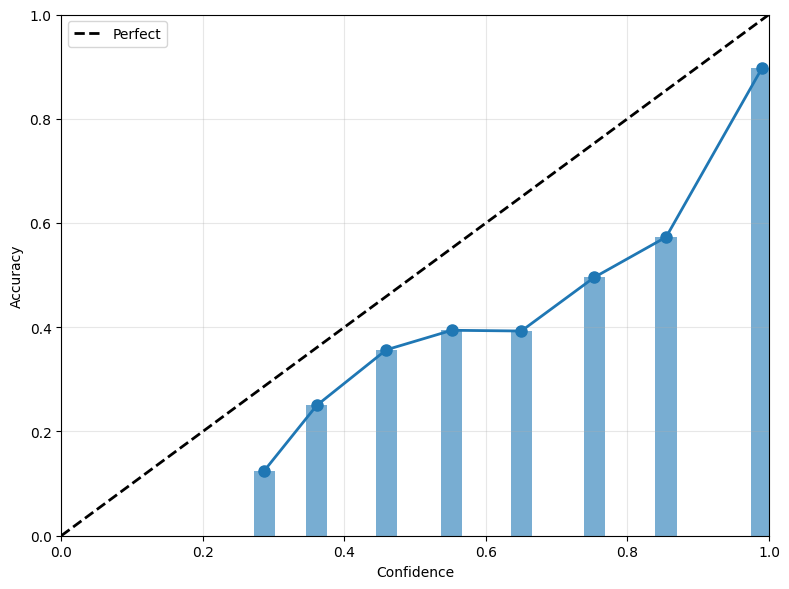

In [34]:
# ECE
preds_std, confs_std, labels_std = get_predictions_and_confidences(resnet_std, test_loader)
ece_resnet_std = calculate_ece(confs_std, preds_std, labels_std)
print(f"ECE (ResNet-18 std): {ece_resnet_std:.4f}")

# NLL
nll_resnet_std = calculate_nll(resnet_std, test_loader)
print(f"NLL (ResNet-18 std): {nll_resnet_std:.4f}")

# Reliability diagram
print("\nReliability Diagram — ResNet-18 Standard:")
plot_reliability_diagram(resnet_std, test_loader)

**ECE = 0.1142** — higher than SmallCNN (0.0293), indicating worse calibration despite
better clean accuracy. The reliability diagram confirms the model is **underconfident**:
accuracy exceeds confidence across all bins, suggesting 10 epochs are insufficient for
full convergence of a model this size.

**NLL = 0.7930** — similar to SmallCNN (0.8185), meaning both models assign comparable
probability mass to the correct class despite the capacity difference.


### Plotting — ECE, Clean Accuracy and Robust Accuracy vs ε


Starting epsilon sweep — ResNet-18 Standard...
  eps=0.00 ... FGSM=80.3%  PGD=80.3%  ECE=0.122
  eps=0.03 ... FGSM=3.3%  PGD=0.0%  ECE=0.911
  eps=0.06 ... FGSM=2.2%  PGD=0.0%  ECE=0.904
  eps=0.13 ... FGSM=2.4%  PGD=0.0%  ECE=0.871
  eps=0.25 ... FGSM=4.0%  PGD=0.0%  ECE=0.846
  eps=0.50 ... FGSM=5.0%  PGD=0.0%  ECE=0.843

Plots:


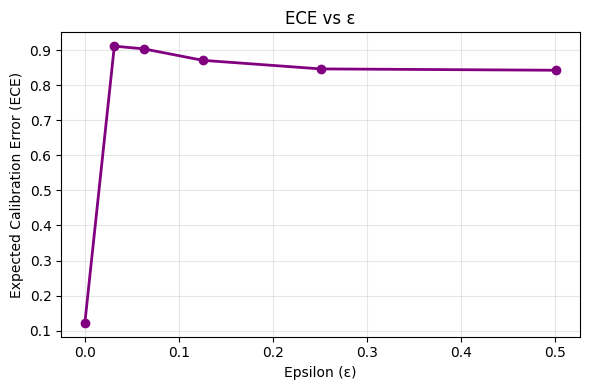

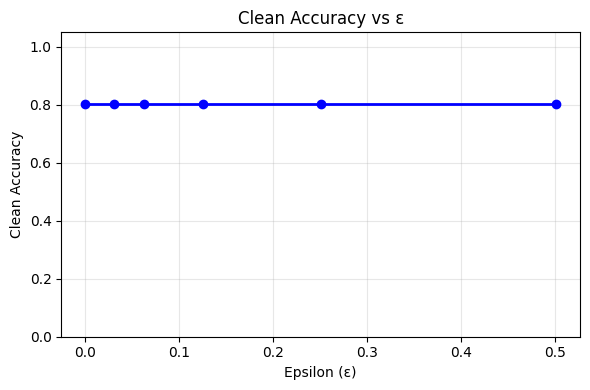

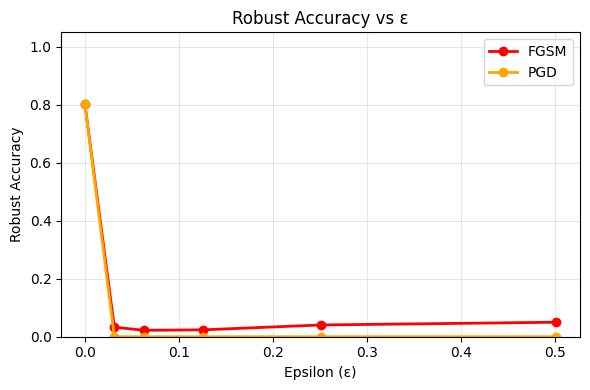

In [35]:
eps_base = 8/255
epsilons = [0.0] + [eps_base * (2**i) for i in range(5)]

ece_std_list       = []
fgsm_std_list      = []
pgd_std_list       = []
clean_std_list     = [clean_acc_resnet_std] * len(epsilons)

print("Starting epsilon sweep — ResNet-18 Standard...")

for eps in epsilons:
    print(f"  eps={eps:.2f} ...", end=" ", flush=True)

    # --- Robust accuracies ---
    if eps == 0.0:
        fgsm_std_list.append(clean_acc_resnet_std)
        pgd_std_list.append(clean_acc_resnet_std)
    else:
        fgsm_std_list.append(eval_under_attack(
            resnet_std, test_loader,
            attack_fn=lambda x, y, e=eps: fgsm_attack(resnet_std, x, y, eps=e)
        ))
        pgd_std_list.append(eval_under_attack(
            resnet_std, test_loader,
            attack_fn=lambda x, y, e=eps: pgd_attack(resnet_std, x, y,
                                                       eps=e, alpha=e/4, steps=10)
        ))

    # --- ECE under FGSM attack ---
    all_preds, all_confs, all_labels = [], [], []
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        x_adv = x if eps == 0.0 else fgsm_attack(resnet_std, x, y, eps=eps)
        with torch.no_grad():
            logits = resnet_std(x_adv)
            probs  = F.softmax(logits, dim=1)
            conf, pred = torch.max(probs, dim=1)
        all_preds.append(pred.cpu().numpy())
        all_confs.append(conf.cpu().numpy())
        all_labels.append(y.cpu().numpy())

    ece_std_list.append(calculate_ece(
        np.concatenate(all_confs),
        np.concatenate(all_preds),
        np.concatenate(all_labels)
    ))
    print(f"FGSM={fgsm_std_list[-1]*100:.1f}%  PGD={pgd_std_list[-1]*100:.1f}%  ECE={ece_std_list[-1]:.3f}")

print("\nPlots:")
plot_ece_vs_epsilon(epsilons, ece_std_list)
plot_clean_acc_vs_epsilon(epsilons, clean_std_list)
plot_robust_acc_vs_epsilon(epsilons, fgsm_std_list, pgd_std_list)

**ECE vs ε:** ECE spikes from 0.114 (clean) to 0.911 at ε=0.03 and remains high across
all epsilons, with a slight dip at ε=0.25 before rising again at ε=0.50. The model
stays confident even when accuracy collapses — overconfident under attack.

**Clean Accuracy vs ε:** Flat line at ~80.8%, confirming clean accuracy is unaffected
by the attack strength used in the sweep.

**Robust Accuracy vs ε:** Both FGSM and PGD collapse at ε=0.03. PGD stays at 0%
throughout. FGSM recovers slightly at larger epsilons (up to 10% at ε=0.50) due to
gradient overshooting — very large perturbations become less effective as a precise attack.


## 2. Adversarial Training — FGSM (ResNet-18)

Now, we'll train our model again with adversarial data generated by `fgsm_attack`, then we'll optimize on the loss functions created by the weighted sum (using a factor lambda) of the loss function of the 'clean' examples and the 'adversarial' examples. We also use a very high number of epochs (100) to be sure that the model is trained correctly. To avoid a decay in the accuracy and overfitting, we also implemented early stopping to this model, with a variable "patience" that can be modified to adapt the early stopping to our needs.




In [36]:
adv_eps = 8/255   # adversarial training strength
lam = 0.5        # mix ratio
epochs = 100      # larger model --> more epochs

In [37]:
# Load the weights of the model to skip the training

device = 'cuda' if torch.cuda.is_available() else 'cpu'
%cd /content/project2/models

from resnet18_adv import ResNet18CIFAR_adv
model_resnet_adv = ResNet18CIFAR_adv().to(device)

%cd /content/project2/models/weights
model_resnet_adv.load_state_dict(torch.load('model_resnet_adv.pth', map_location=device))

/content/project2/models
/content/project2/models/weights


<All keys matched successfully>

In [38]:
# Skip this block if model already loaded
"""
%cd /content/project2/models
from resnet18_adv import ResNet18CIFAR_adv

# In each step we introduce adversarial images
model_resnet_adv = ResNet18CIFAR_adv(epochs=epochs, eps=adv_eps, lam=lam, patience = 15).to(device)
model_resnet_adv.trainloop(train_loader, val_loader)

# Save weigths
%cd /content/project2/models/weights
torch.save(model_resnet_adv.state_dict(), "model_resnet_adv.pth")
"""

'\n%cd /content/project2/models\nfrom resnet18_adv import ResNet18CIFAR_adv\n\n# In each step we introduce adversarial images\nmodel_resnet_adv = ResNet18CIFAR_adv(epochs=epochs, eps=adv_eps, lam=lam, patience = 15).to(device)\nmodel_resnet_adv.trainloop(train_loader, val_loader)\n\n# Save weigths\n%cd /content/project2/models/weights\ntorch.save(model_resnet_adv.state_dict(), "model_resnet_adv.pth")\n'

### Evaluation


We will use the function `eval_robust_accuracy`, which was implemented for the evaluation of the adversarial training of the small dataset.

In [39]:
# Clean accuracy
clean_acc = model_resnet_adv.eval_accuracy(test_loader)

# Robust accuracy under FGSM/PGD
fgsm_acc = eval_robust_accuracy(
    model_resnet_adv, test_loader,
    attack_fn=lambda x, y: fgsm_attack(model_resnet_adv, x, y, eps=8/255)
)

pgd_acc = eval_robust_accuracy(
    model_resnet_adv, test_loader,
    attack_fn=lambda x, y: pgd_attack(model_resnet_adv, x, y, eps=(8/255), alpha=0.03, steps=20)
)

In [40]:
print(f"Clean accuracy:  {clean_acc*100:.2f}%")
print(f"Robust accuracy under FGSM: {fgsm_acc*100:.2f}%")
print(f"Robust accuracy under PGD: {pgd_acc*100:.2f}%")

Clean accuracy:  77.76%
Robust accuracy under FGSM: 37.06%
Robust accuracy under PGD: 26.30%


Which are expected values. Our adversarial model has been trained on FGSM attacks, not on PGD.

Nevertheless a higher robust accuracy under FGSM attacks would be expected.

As we did with the non-adversarial one, let's get a big picture of the accuracy under different values of epsilon:

In [41]:
eps = 8/255 #standard value
eps_list = [0.0] + [eps * (2**i) for i in range(5)]
steps = 20

clean_acc = model_resnet_adv.eval_accuracy(test_loader)
print("Clean accuracy:", clean_acc)

fgsm_accs = []
pgd_accs  = []

for eps in eps_list:
    if eps == 0.0:
        fgsm_accs.append(clean_acc)
        pgd_accs.append(clean_acc)
        continue

    fgsm_acc = eval_under_attack(
        model_resnet_adv, test_loader,
        attack_fn=lambda x, y, eps=eps: fgsm_attack(model_resnet_adv, x, y, eps=eps)
    )
    pgd_acc = eval_under_attack(
        model_resnet_adv, test_loader,
        attack_fn=lambda x, y, eps=eps: pgd_attack(model_resnet_adv, x, y, eps=eps, alpha=eps/10, steps=steps)
    )
    fgsm_accs.append(fgsm_acc)
    pgd_accs.append(pgd_acc)
    print(f"eps={eps:.10f}  FGSM={fgsm_acc*100:.2f}%  PGD={pgd_acc*100:.2f}%")


Clean accuracy: 0.7776
eps=0.0313725490  FGSM=37.06%  PGD=28.70%
eps=0.0627450980  FGSM=15.77%  PGD=4.22%
eps=0.1254901961  FGSM=4.41%  PGD=0.06%
eps=0.2509803922  FGSM=4.59%  PGD=0.00%
eps=0.5019607843  FGSM=11.49%  PGD=0.00%


Now we will complete the evaluation with the ECC, NLL and the Reliability Diagram (making use of our pre-defined functions).

Adversarial Model ECE: 0.0351

Adversarial Model NLL: 0.6821
Reliability Diagram (Adversarial Model):


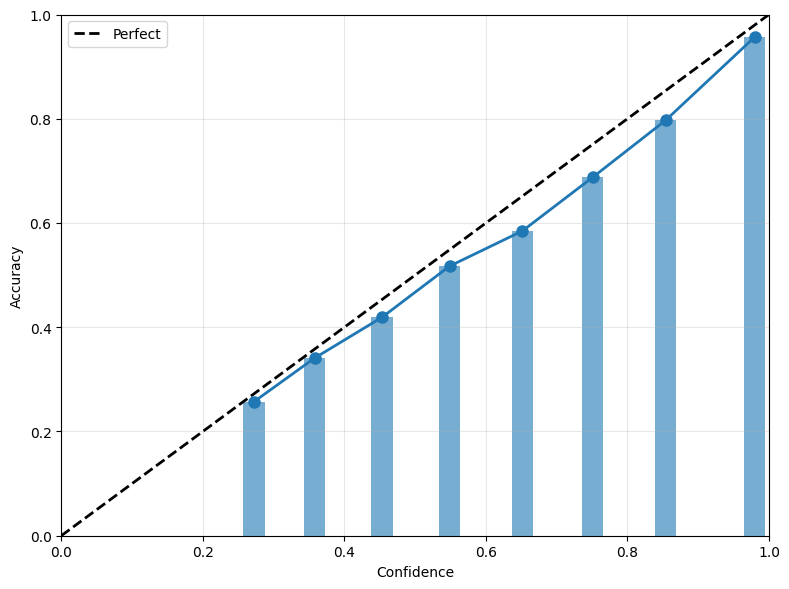

In [42]:
# First, we will extract predictions, confidences and labels (with our function)
preds, confs, labels = get_predictions_and_confidences(model_resnet_adv, test_loader)
# Now we can calculate the ECE
ece_adv = calculate_ece(confs, preds, labels)
print(f"Adversarial Model ECE: {ece_adv:.4f}\n")

# Second, we calculate NLL on clean data
nll_adv = calculate_nll(model_resnet_adv, test_loader)
print(f"Adversarial Model NLL: {nll_adv:.4f}")

# After that, we plot Reliability Diagram
print("Reliability Diagram (Adversarial Model):")
plot_reliability_diagram(model_resnet_adv, test_loader)

### Plotting

Before the analysis part, we will generate the following plots:
1. ECE vs ε
2. Clean accuracy vs ε
3. Robust accuracy (FGSM and PGD) vs ε

We will use the plotting functions defined in part 1 (`plot_ece_vs_epsilon`, `plot_clean_acc_vs_epsilon`, `plot_robust_acc_vs_epsilon`)

Starting epsilon evaluation loop...
Evaluating for epsilon = 0.0...
Evaluating for epsilon = 0.03137254901960784...
Evaluating for epsilon = 0.06274509803921569...
Evaluating for epsilon = 0.12549019607843137...
Evaluating for epsilon = 0.25098039215686274...
Evaluating for epsilon = 0.5019607843137255...

Evaluation complete. Generating plots...


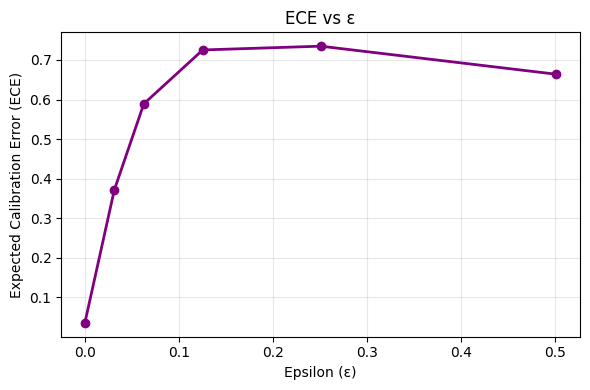

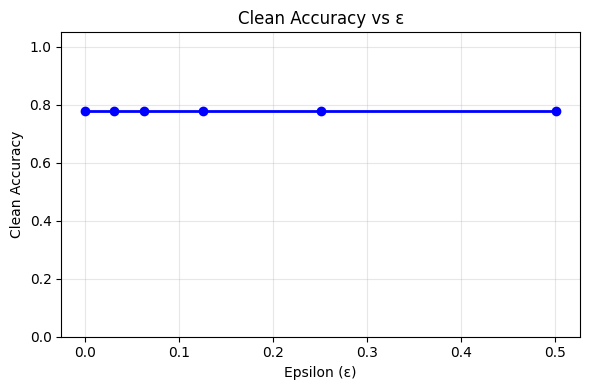

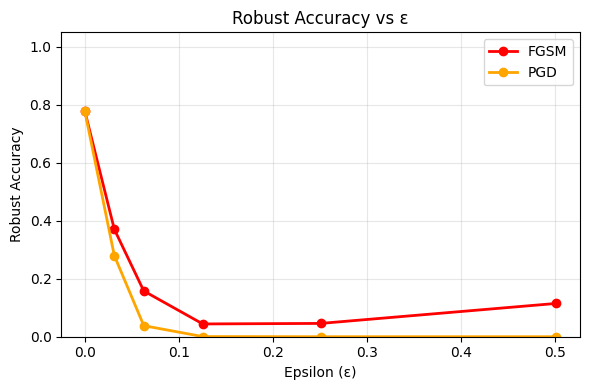

In [43]:
eps = 8/255 #standard value
epsilons = [0.0] + [eps * (2**i) for i in range(5)]

ece_list = []
fgsm_acc_list = []
pgd_acc_list = []

clean_acc_list = [clean_acc] * len(epsilons)

device = next(model_resnet_adv.parameters()).device

print("Starting epsilon evaluation loop...")

for eps in epsilons:
    print(f"Evaluating for epsilon = {eps}...")

    # Define attack functions using your mate's exact functions
    fgsm_fn = lambda x, y: fgsm_attack(model_resnet_adv, x, y, eps=eps)
    pgd_fn = lambda x, y: pgd_attack(model_resnet_adv, x, y, eps=eps, alpha=eps/4, steps=10)

    # Robust Accuracies (using your mate's eval_under_attack)
    fgsm_acc_list.append(eval_under_attack(model_resnet_adv, test_loader, fgsm_fn))
    pgd_acc_list.append(eval_under_attack(model_resnet_adv, test_loader, pgd_fn))

    # ECE under FGSM Attack
    all_preds, all_confs, all_labels = [], [], []

    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        # Generate the attacked images (gradients needed here!)
        x_adv = fgsm_fn(x, y)

        # Predict on the attacked images
        with torch.no_grad():
            logits = model_resnet_adv(x_adv)
            probs = F.softmax(logits, dim=1)
            confs, preds = torch.max(probs, dim=1)

            all_preds.append(preds.cpu().numpy())
            all_confs.append(confs.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_confs = np.concatenate(all_confs)
    all_labels = np.concatenate(all_labels)

    # Calculate ECE using your mate's function
    ece_list.append(calculate_ece(all_confs, all_preds, all_labels))

print("\nEvaluation complete. Generating plots...")

# Finally, we generate the plots
plot_ece_vs_epsilon(epsilons, ece_list)
plot_clean_acc_vs_epsilon(epsilons, clean_acc_list)
plot_robust_acc_vs_epsilon(epsilons, fgsm_acc_list, pgd_acc_list)

**ECE vs ε:** ECE spikes from 0 (clean) to 0.73 at ε=0.12 and stays very high for all the higher epsilon values. The model
stays confident even when accuracy collapses — overconfident under attack.

**Clean Accuracy vs ε:** Flat line at ~77%, confirming clean accuracy is unaffected
by the attack strength used in the sweep.

**Robust Accuracy vs ε:** Both FGSM and PGD robust accuracies decrease pretty quickly. PGD stays at 0%, whereas FGSM recovers slightly at larger epsilons (up to 10% at ε=0.5) due to gradient overshooting — very large perturbations become less effective than a precise attack.

### Analysis

**1. Does FGSM-based AT improve robustness against: FGSM? PGD?**
* **Against FGSM:** Yes, it does, but not as much as we expected. As seen in the *Robust Accuracy vs ε* plot, the model has its highest accuracy against FGSM attacks at ε=8/255 (which matches the $\epsilon$ used during training).
* **Against PGD:** No, it fails completely. The accuracy under PGD attack vanishes to near 0% almost immediately. This is a classic example of **overfitting**. The model memorized the single-step FGSM perturbations used during training but failed to learn generalized robustness against iterative, multi-step attacks like PGD.

**2. Does increased robustness correlate with better or worse calibration?**

Generally, adversarial training worsens calibration on clean data (increasing NLL and ECE compared to a standard model) because the model is forced to balance learning clean features and adversarial noise. While the model is highly robust to FGSM, its calibration under attack still degrades severely. True robustness does not automatically guarantee good calibration.

**3. Are adversarially trained models overconfident or underconfident?**

On clean data, adversarially trained models tend to be slightly **underconfident** compared to standard models because the training process penalizes extreme overconfidence on modified images, smoothing out the predicted probabilities. However, under heavy adversarial attacks (as ε increases), the model's accuracy drops far faster than its confidence, causing it to become highly **overconfident** in its incorrect predictions.

**4. How do calibration metrics evolve as ε increases?**

*(Based on the ECE vs ε plot)* The evolution of the ECE perfectly demonstrates the model's overfitting to the specific training epsilon (`adv_eps = 8/255`).
* At **$\epsilon = 0$**, the ECE is low (~0.05) because the model evaluates clean data reasonably well.
* At **$\epsilon = 8/255$**, the ECE starts to increase. Because the model was only trained on perturbations of size 8/255, the attack is now generating the exact specific noise distribution the model memorized during training, so its accuracy recovers and its confidence aligns with its predictions.
* For **$\epsilon$ > 8/255**, the noise enters unfamiliar territory, and the ECE skyrockets to roughly 0.75.